In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


The tokenizer you are loading from '/content/drive/MyDrive/PDS_Snapaddy/models/bert_sen_Profs_JobBERT_PRO_uncapped' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cpu


Accuracy: 0.5617977528089888
              precision    recall  f1-score   support

    Director       0.77      0.97      0.86        34
      Junior       0.08      0.67      0.14        12
        Lead       0.79      0.68      0.73       125
  Management       0.93      0.83      0.88       192
Professional       0.87      0.12      0.22       216
      Senior       0.23      0.86      0.37        44

    accuracy                           0.56       623
   macro avg       0.61      0.69      0.53       623
weighted avg       0.81      0.56      0.57       623



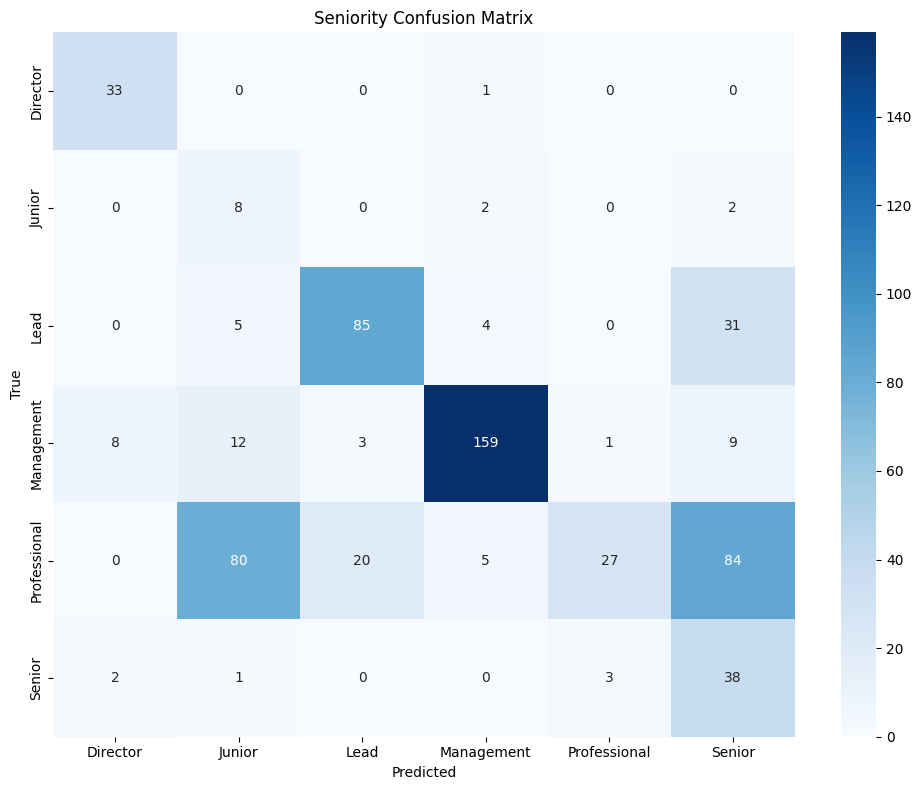

In [ ]:
from transformers import pipeline
import pandas as pd
import json
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

MODEL_PATH = "/models/bert_sen_Profs_JobBERT_PRO_uncapped"
JSON_PATH = "../Data/Original Data/linkedin-cvs-annotated.json"

# 1. model load 
classifier = pipeline("text-classification", model=MODEL_PATH, tokenizer=MODEL_PATH)

# 2. load data and flat
job_df = pd.read_json(JSON_PATH)
records = [val for col in job_df.columns for val in job_df[col] if isinstance(val, dict)]
active = pd.DataFrame(records)[lambda df: df["status"] == "ACTIVE"].copy()
texts = active["position"].fillna("").tolist()

# 3. predict
preds = classifier(texts, top_k=1) 

active["predicted_seniority"] = [p[0]['label'] for p in preds]  
active["confidence"] = [p[0]['score'] for p in preds]

# 4. Label-Mapping
with open(f"{MODEL_PATH}/label_encoder.json", "r", encoding="utf-8") as f:
    le_info = json.load(f)
id2label = {int(k): v for k, v in le_info["mapping"].items()}

def decode_label(label_str):
    if isinstance(label_str, str) and label_str.startswith("LABEL_"):
        idx = int(label_str.split("_")[1])
        return id2label.get(idx, label_str)
    return label_str

active["predicted_seniority_decoded"] = active["predicted_seniority"].apply(decode_label)

# 5. Evaluation 
df_eval = active.dropna(subset=["seniority", "predicted_seniority_decoded"])
y_true = df_eval["seniority"]
y_pred = df_eval["predicted_seniority_decoded"]

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

# Confusion Matrix
labels = sorted(df_eval["seniority"].unique())
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Seniority Confusion Matrix")
plt.tight_layout(); plt.show()

# Fehler speichern
errors = df_eval[df_eval["seniority"] != df_eval["predicted_seniority_decoded"]]
active.to_csv("/results/linkedin_seniority_predictions.csv", index=False)
df_eval.to_csv("/results/linkedin_seniority_eval.csv", index=False)
errors.to_csv("/results/linkedin_seniority_errors.csv", index=False)

In [ ]:
from transformers import pipeline
import pandas as pd
import json
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

MODEL_PATH = "/models/bert_sen_Profs_JobBERT_PRO_uncapped"
JSON_PATH = "../Data/Original Data/linkedin-cvs-annotated.json"


classifier = pipeline("text-classification", model=MODEL_PATH, tokenizer=MODEL_PATH)


job_df = pd.read_json(JSON_PATH)
records = [val for col in job_df.columns for val in job_df[col] if isinstance(val, dict)]
active = pd.DataFrame(records)[lambda df: df["status"] == "ACTIVE"].copy()
texts = active["position"].fillna("").tolist()


preds = classifier(texts, top_k=1)  

active["predicted_seniority"] = [p[0]['label'] for p in preds] 
active["confidence"] = [p[0]['score'] for p in preds]


with open(f"{MODEL_PATH}/label_encoder.json", "r", encoding="utf-8") as f:
    le_info = json.load(f)
id2label = {int(k): v for k, v in le_info["mapping"].items()}

def decode_label(label_str):
    if isinstance(label_str, str) and label_str.startswith("LABEL_"):
        idx = int(label_str.split("_")[1])
        return id2label.get(idx, label_str)
    return label_str

active["predicted_seniority_decoded"] = active["predicted_seniority"].apply(decode_label)

# 5. Evaluation 
df_eval = active.dropna(subset=["seniority", "predicted_seniority_decoded"])
y_true = df_eval["seniority"]
y_pred = df_eval["predicted_seniority_decoded"]

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

# Confusion Matrix
labels = sorted(df_eval["seniority"].unique())
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Seniority Confusion Matrix")
plt.tight_layout(); plt.show()

# Fehler speichern
errors = df_eval[df_eval["seniority"] != df_eval["predicted_seniority_decoded"]]
active.to_csv("/results/linkedin_seniority_predictions.csv", index=False)
df_eval.to_csv("/results/linkedin_seniority_eval.csv", index=False)
errors.to_csv("/results/linkedin_seniority_errors.csv", index=False)

The tokenizer you are loading from '/content/drive/MyDrive/PDS_Snapaddy/models/bert_sen_Profs_JobBERT_PRO_uncapped' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cpu


🔄 Übersetze 623 Texts...


/usr/local/lib/python3.12/dist-packages/pandas/core/algorithms.py:1743: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  return lib.map_infer(values, mapper, convert=convert)


✅ EN-Übersetzt! Accuracy: 0.5617977528089888
              precision    recall  f1-score   support

    Director       0.77      0.97      0.86        34
      Junior       0.08      0.67      0.14        12
        Lead       0.79      0.68      0.73       125
  Management       0.93      0.83      0.88       192
Professional       0.87      0.12      0.22       216
      Senior       0.23      0.86      0.37        44

    accuracy                           0.56       623
   macro avg       0.61      0.69      0.53       623
weighted avg       0.81      0.56      0.57       623



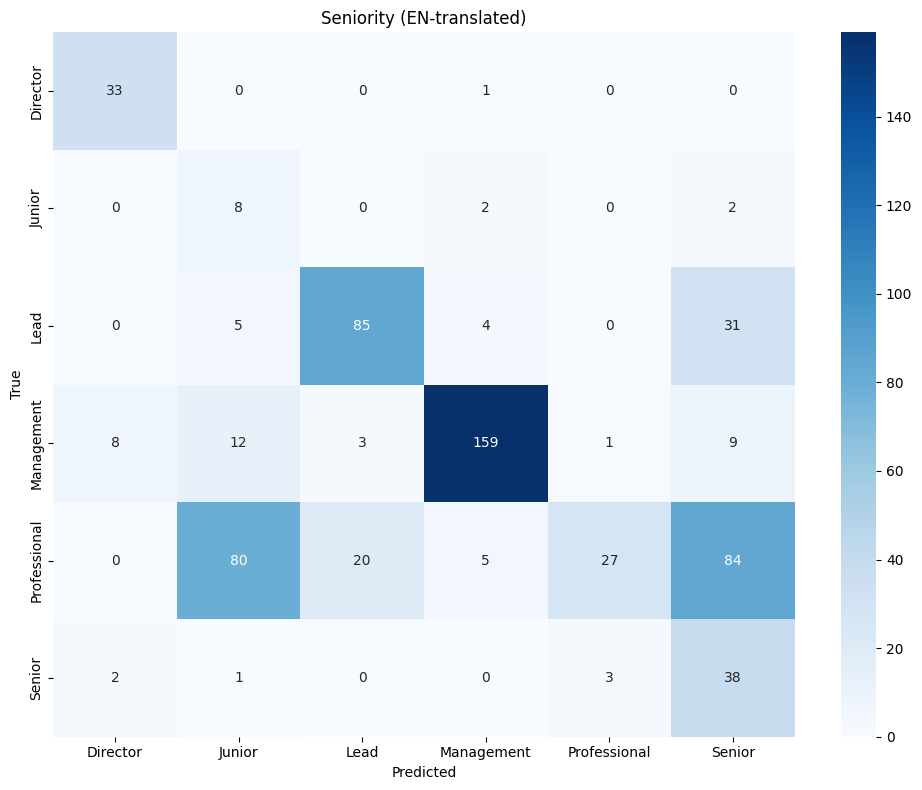

In [ ]:
from transformers import pipeline
import pandas as pd
import json, requests
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import googletrans  # pip install googletrans==4.0.0-rc1

MODEL_PATH = "/models/bert_sen_Profs_JobBERT_PRO_uncapped"
JSON_PATH = "../Data/Original Data/linkedin-cvs-annotated.json"

# 1. Translator + Classifier load
translator = googletrans.Translator()  # Free, schnell!
classifier = pipeline("text-classification", model=MODEL_PATH, tokenizer=MODEL_PATH)

def translate_to_en(text):
    """translate  EN (batch-safe)"""
    if pd.isna(text) or not text.strip():
        return ""
    try:
        result = translator.translate(text.strip(), dest='en')
        return result.text
    except:
        return text.strip()  # Fallback Original

# 2. Daten laden
job_df = pd.read_json(JSON_PATH)
records = [val for col in job_df.columns for val in job_df[col] if isinstance(val, dict)]
active = pd.DataFrame(records)[lambda df: df["status"] == "ACTIVE"].copy()

# 3. *translate
print("translate", len(active), "Texts...")
active["position_en"] = active["position"].fillna("").apply(translate_to_en)
texts_en = active["position_en"].fillna("").tolist()

# 4. Predictions  EN
preds = classifier(texts_en, top_k=1)
active["predicted_seniority"] = [p[0]['label'] for p in preds]
active["confidence"] = [p[0]['score'] for p in preds]

# 5. Decode 
with open(f"{MODEL_PATH}/label_encoder.json", "r", encoding="utf-8") as f:
    le_info = json.load(f)
id2label = {int(k): v for k, v in le_info["mapping"].items()}

def decode_label(label_str):
    if isinstance(label_str, str) and label_str.startswith("LABEL_"):
        idx = int(label_str.split("_")[1])
        return id2label.get(idx, label_str)
    return label_str

active["predicted_seniority_decoded"] = active["predicted_seniority"].apply(decode_label)

# 6. Eval 
df_eval = active.dropna(subset=["seniority", "predicted_seniority_decoded"])
y_true = df_eval["seniority"]
y_pred = df_eval["predicted_seniority_decoded"]

print("EN-translated! Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

# Confusion Matrix
labels = sorted(df_eval["seniority"].unique())
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Seniority (EN-translated)")
plt.tight_layout(); plt.show()

# Save with EN-Texts
active.to_csv("/results/linkedin_seniority_en_translated.csv", index=False)
df_eval.to_csv("/results/linkedin_seniority_eval_en.csv", index=False)